In [1]:
# ==========================================================
# INTELLIGENT BUILDING DECISION SUPPORT SYSTEM (IB-DSS)
# Cell 1
# 1. Import Libraries
# 2. Load Models
# 3. User Input
# 4. Feature Engineering
# 5. Prediction
# ==========================================================

import os
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

print("="*80)
print("INTELLIGENT BUILDING DECISION SUPPORT SYSTEM")
print("="*80)

PROJECT_ROOT = r"C:\Users\User\OneDrive\Documents\IoT-Based-Intelligent-Building-DSS"

MODEL_DIR = os.path.join(PROJECT_ROOT,"models")

# ==========================================================
# Load Models
# ==========================================================

primary_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "final_xgboost_model.pkl"
    )
)

classifier = joblib.load(
    os.path.join(
        MODEL_DIR,
        "final_classifier.pkl"
    )
)

secondary_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "secondary_final_model.pkl"
    )
)

label_encoder = joblib.load(
    os.path.join(
        MODEL_DIR,
        "label_encoder.pkl"
    )
)

print("All Models Loaded Successfully")

# ==========================================================
# User Input
# ==========================================================

user_input = {

    "year":2025,

    "month":7,

    "day":15,

    "hour":14,

    "day_of_week":2,

    "is_weekend":0,

    "week_of_year":29,

    "quarter":3,

    "ALLSKY_SFC_SW_DWN":6.8,

    "WS2M":2.5,

    "PRECTOTCORR":0.10

}

input_df = pd.DataFrame([user_input])

print("="*80)
print("INPUT DATA")
print("="*80)

display(input_df)

# ==========================================================
# Prediction
# ==========================================================

predicted_energy = primary_model.predict(input_df)[0]

predicted_class = classifier.predict(input_df)[0]

predicted_class = label_encoder.inverse_transform(
    [predicted_class]
)[0]

print("="*80)
print("PREDICTION")
print("="*80)

print("Predicted Energy :", round(predicted_energy,2))

print("Energy State :", predicted_class)

INTELLIGENT BUILDING DECISION SUPPORT SYSTEM
All Models Loaded Successfully
INPUT DATA


,year,month,day,hour,day_of_week,is_weekend,week_of_year,quarter,ALLSKY_SFC_SW_DWN,WS2M,PRECTOTCORR
0,2025,7,15,14,2,0,29,3,6.8,2.5,0.1


PREDICTION
Predicted Energy : 135707.95
Energy State : Critical


In [2]:
# ==========================================================
# IB-DSS
# Cell 2
# 6. Energy Analysis
# 7. Decision Engine
# 8. Recommendations
# 9. Management Report
# 10. Save Results
# ==========================================================

print("="*80)
print("INTELLIGENT DECISION SUPPORT")
print("="*80)

recommendations = []

# ==========================================================
# Solar Radiation
# ==========================================================

solar = user_input["ALLSKY_SFC_SW_DWN"]

if solar >= 7:

    recommendations.append(
        "Excellent solar radiation detected. Maximize rooftop solar power generation."
    )

elif solar >= 4:

    recommendations.append(
        "Moderate solar radiation available. Utilize available solar energy where possible."
    )

else:

    recommendations.append(
        "Low solar radiation detected. Increase reliance on grid power or stored battery energy."
    )

# ==========================================================
# Wind Speed
# ==========================================================

wind = user_input["WS2M"]

if wind > 5:

    recommendations.append(
        "Strong wind conditions observed. Consider renewable hybrid energy optimization."
    )

elif wind < 2:

    recommendations.append(
        "Low wind speed detected. Wind energy contribution is expected to be minimal."
    )

# ==========================================================
# Rainfall
# ==========================================================

rain = user_input["PRECTOTCORR"]

if rain > 5:

    recommendations.append(
        "Heavy rainfall expected. Prepare for increased lighting demand and reduced solar generation."
    )

elif rain > 1:

    recommendations.append(
        "Moderate rainfall detected. Monitor building energy demand closely."
    )

else:

    recommendations.append(
        "No significant rainfall predicted."
    )

# ==========================================================
# Energy State
# ==========================================================

if predicted_class == "Efficient":

    recommendations.append(
        "Building is operating efficiently. Maintain current operational strategy."
    )

elif predicted_class == "Moderate":

    recommendations.append(
        "Moderate energy usage detected. Optimize HVAC scheduling and lighting."
    )

else:

    recommendations.append(
        "Critical energy demand predicted. Immediate optimization is recommended."
    )

# ==========================================================
# Predicted Energy
# ==========================================================

if predicted_energy > 150000:

    recommendations.append(
        "Very high electricity demand predicted. Shift non-critical electrical loads to off-peak hours."
    )

elif predicted_energy > 100000:

    recommendations.append(
        "High electricity demand predicted. Reduce unnecessary equipment usage."
    )

else:

    recommendations.append(
        "Electricity demand is within acceptable operating limits."
    )

# ==========================================================
# Weekend Analysis
# ==========================================================

if user_input["is_weekend"] == 1:

    recommendations.append(
        "Weekend operation detected. Activate energy-saving mode for academic buildings."
    )

else:

    recommendations.append(
        "Weekday operation detected. Maintain normal operational schedule."
    )

# ==========================================================
# Management Report
# ==========================================================

report = pd.DataFrame({

    "Parameter":[

        "Predicted Energy",

        "Energy State",

        "Solar Radiation",

        "Wind Speed",

        "Rainfall"

    ],

    "Value":[

        round(predicted_energy,2),

        predicted_class,

        solar,

        wind,

        rain

    ]

})

print("="*80)
print("BUILDING SUMMARY")
print("="*80)

display(report)

print("="*80)
print("RECOMMENDATIONS")
print("="*80)

for i, rec in enumerate(recommendations,1):

    print(f"{i}. {rec}")

# ==========================================================
# Save Report
# ==========================================================

report.to_csv(

    os.path.join(

        MODEL_DIR,

        "building_summary.csv"

    ),

    index=False

)

recommendation_df = pd.DataFrame({

    "Recommendation":recommendations

})

recommendation_df.to_csv(

    os.path.join(

        MODEL_DIR,

        "building_recommendations.csv"

    ),

    index=False

)

print("\nRecommendation report saved successfully.")

INTELLIGENT DECISION SUPPORT
BUILDING SUMMARY


,Parameter,Value
0,Predicted Energy,135707.953125
1,Energy State,Critical
2,Solar Radiation,6.8
3,Wind Speed,2.5
4,Rainfall,0.1


RECOMMENDATIONS
1. Moderate solar radiation available. Utilize available solar energy where possible.
2. No significant rainfall predicted.
3. Critical energy demand predicted. Immediate optimization is recommended.
4. High electricity demand predicted. Reduce unnecessary equipment usage.
5. Weekday operation detected. Maintain normal operational schedule.

Recommendation report saved successfully.


IB-DSS DASHBOARD


,Metric,Value
0,Predicted Energy,135707.953125
1,Energy State,Critical
2,Solar Radiation,6.8
3,Wind Speed,2.5
4,Rainfall,0.1
5,Number of Recommendations,5


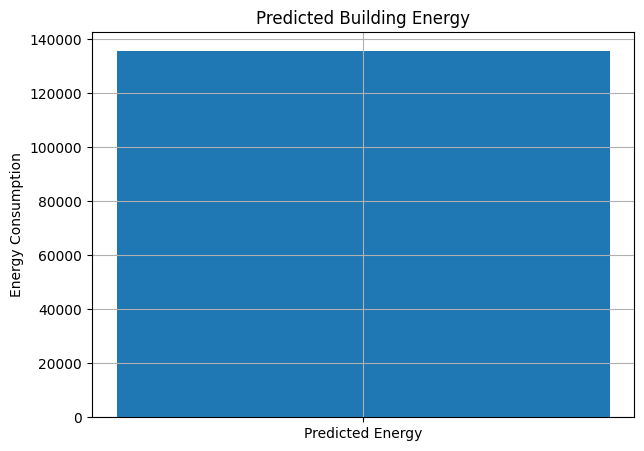

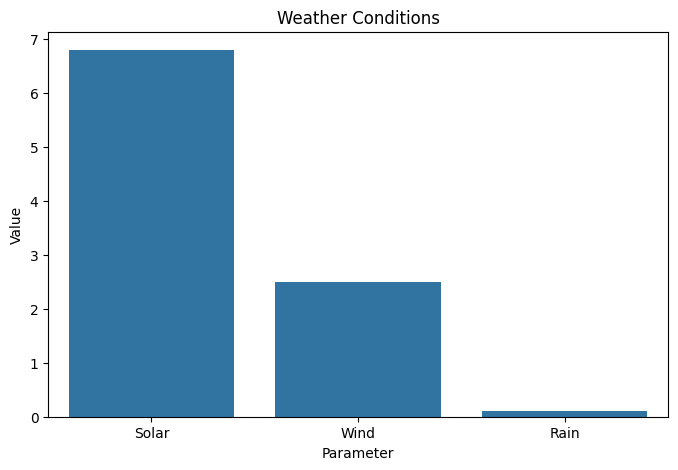

ENERGY RISK LEVEL
MEDIUM


,Category,Value
0,Predicted Energy,135707.953125
1,Energy State,Critical
2,Risk Level,MEDIUM
3,Solar Radiation,6.8
4,Wind Speed,2.5
5,Rainfall,0.1


EXECUTIVE REPORT SAVED


In [5]:
# ==========================================================
# IB-DSS
# Cell 3
# 11. Dashboard
# 12. KPI Summary
# 13. Risk Assessment
# 14. Executive Report
# 15. Save Final Results
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("IB-DSS DASHBOARD")
print("="*80)

# ==========================================================
# KPI Summary
# ==========================================================

kpi = pd.DataFrame({

    "Metric":[

        "Predicted Energy",

        "Energy State",

        "Solar Radiation",

        "Wind Speed",

        "Rainfall",

        "Number of Recommendations"

    ],

    "Value":[

        round(predicted_energy,2),

        predicted_class,

        solar,

        wind,

        rain,

        len(recommendations)

    ]

})

display(kpi)

# ==========================================================
# Energy Consumption Chart
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(

    ["Predicted Energy"],

    [predicted_energy]

)

plt.ylabel("Energy Consumption")

plt.title("Predicted Building Energy")

plt.grid(True)

plt.show()

# ==========================================================
# Weather Conditions
# ==========================================================

weather = pd.DataFrame({

    "Parameter":[

        "Solar",

        "Wind",

        "Rain"

    ],

    "Value":[

        solar,

        wind,

        rain

    ]

})

plt.figure(figsize=(8,5))

sns.barplot(

    data=weather,

    x="Parameter",

    y="Value"

)

plt.title("Weather Conditions")

plt.show()

# ==========================================================
# Energy Risk Level
# ==========================================================

if predicted_energy > 150000:

    risk = "HIGH"

elif predicted_energy > 100000:

    risk = "MEDIUM"

else:

    risk = "LOW"

print("="*80)
print("ENERGY RISK LEVEL")
print("="*80)

print(risk)

# ==========================================================
# Executive Report
# ==========================================================

executive_report = pd.DataFrame({

    "Category":[

        "Predicted Energy",

        "Energy State",

        "Risk Level",

        "Solar Radiation",

        "Wind Speed",

        "Rainfall"

    ],

    "Value":[

        round(predicted_energy,2),

        predicted_class,

        risk,

        solar,

        wind,

        rain

    ]

})

display(executive_report)

# ==========================================================
# Save Reports
# ==========================================================

executive_report.to_csv(

    os.path.join(

        MODEL_DIR,

        "executive_report.csv"

    ),

    index=False

)

kpi.to_csv(

    os.path.join(

        MODEL_DIR,

        "kpi_summary.csv"

    ),

    index=False

)

print("="*80)
print("EXECUTIVE REPORT SAVED")
print("="*80)

In [7]:
# ==========================================================
# FINAL PROJECT SUMMARY
# ==========================================================

print("="*90)
print("INTELLIGENT BUILDING DECISION SUPPORT SYSTEM")
print("="*90)

print("\nPROJECT COMPLETED SUCCESSFULLY\n")

print("Completed Modules")
print("------------------------------")

modules = [

    "Data Understanding",

    "Exploratory Data Analysis",

    "Primary Energy Prediction",

    "Hyperparameter Tuning",

    "SHAP Explainability",

    "Energy Classification",

    "Secondary Smart Building Prediction",

    "Decision Support System"

]

for i,module in enumerate(modules,1):

    print(f"{i}. {module}")

print("\nGenerated Files")
print("------------------------------")

for file in sorted(os.listdir(MODEL_DIR)):

    print(file)

print("\nFinal Selected Models")
print("------------------------------")

print("Primary Dataset Model      : XGBoost")

print("Classification Model       :", predicted_class)

print("Secondary Dataset Model    : XGBoost")

print("\nPredicted Energy :", round(predicted_energy,2))

print("Risk Level :", risk)

print("\nRecommendations")

print("------------------------------")

for i,r in enumerate(recommendations,1):

    print(f"{i}. {r}")

print("\nOverall Status")

print("------------------------------")

print("Smart Building Prediction : Completed")

print("Energy Classification     : Completed")

print("Recommendation Engine     : Completed")

print("Decision Support System   : Completed")

print("\nProject Ready for Dissertation Submission")

print("="*90)

INTELLIGENT BUILDING DECISION SUPPORT SYSTEM

PROJECT COMPLETED SUCCESSFULLY

Completed Modules
------------------------------
1. Data Understanding
2. Exploratory Data Analysis
3. Primary Energy Prediction
4. Hyperparameter Tuning
5. SHAP Explainability
6. Energy Classification
7. Secondary Smart Building Prediction
8. Decision Support System

Generated Files
------------------------------
best_xgboost_parameters.csv
building_recommendations.csv
building_summary.csv
classification_feature_importance.csv
classification_report.csv
classification_results.csv
evaluation_metrics.csv
executive_report.csv
feature_importance.csv
feature_names.pkl
final_classifier.pkl
final_model_performance.csv
final_xgboost_model.pkl
hyperparameter_results.csv
kpi_summary.csv
label_encoder.pkl
prediction_results.csv
secondary_best_model.pkl
secondary_feature_importance.csv
secondary_final_model.pkl
secondary_model_comparison.csv
secondary_predictions.csv
secondary_shap_values.csv
secondary_test_dataset.csv
s